In [1]:
%pip install seaborn
%pip install matplotlib
%pip install pandas
%pip install pyfonts
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ------------------------------
# 1: RUN FOR UNIVERSAL SETTINGS
# ------------------------------

# Load libraries
import pandas as pd
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import calendar
from datetime import date
import os
from pyfonts import load_google_font

# COLOR SETTINGS
# ------------------------------

# Gradients, see Design Approach tab in our project Google doc.
unicolor_darkblue_gradient = [
    [0.0, "#EEEBE6"],
    [0.5, "#19649F"],
    [1.0, "#092439"],
]

unicolor_orange_gradient = [
    [0.0, "#EEEBE6"],
    [0.5, "#DBBE48"],
    [1.0, "#C97C08"],
]

bicolor_standard_gradient = [
    [0.0, "#19659e"],
    [0.5, "#dbbe48"],
    [1.0, "#A74956"],
]

bicolor_whitemiddle_gradient = [
    [0.0, "#19659e"],
    [0.5, "#F9F7F4"],
    [1.0, "#C97C08"],
]

# Simple list versions of the gradients, which we can use for seaborn color palettes:
bicolor_standard_list = ["#19659e", "#dbbe48", "#A74956"]

# For matplotlib, need to create a cmap object from the gradients defined above:
def create_matplotlib_cmap(name, gradient_list):
    tupled_list = list(tuple(x) for x in gradient_list)
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list(name, tupled_list)
    return cmap

# palettes for plots
core_palette = ['#092439','#19649F','#F9F7F4','#EEEBE6','#E0DCD5','#746F68']
additional_colors = ['#53ADA4','#DBBE48','#C97C08','#70A8D2','#A74956']

# Make discrete colormap for "crest"
crest_disc = sns.color_palette("crest", 5)

unicolor_darkblue_cmap = create_matplotlib_cmap("unicolor_darkblue", unicolor_darkblue_gradient)
unicolor_orange_cmap = create_matplotlib_cmap("unicolor_orange", unicolor_orange_gradient)
bicolor_standard_cmap = create_matplotlib_cmap("bicolor_standard", bicolor_standard_gradient)
bicolor_whitemiddle_cmap = create_matplotlib_cmap("bicolor_whitemiddle", bicolor_whitemiddle_gradient)

# Helper function to create a color palette of n colors from a given cmap, which we can use with matplotlib:
def create_color_palette(cmap, num_colors, start=0.2, end=1):
    """Create a color palette from a given colormap.

    Args:
        cmap (LinearSegmentedColormap): The colormap from which to create the palette.
        num_colors (int): The number of colors to include in the palette.
        start (float, optional): The starting point for the color interpolation. Defaults to 0.2.
        end (float, optional): The ending point for the color interpolation. Defaults to 1.

    Returns:
        ListedColormap: A colormap containing the specified number of colors.
    """    
    return cmap.resampled(num_colors)(np.linspace(start, end, num_colors))

# Set formatting options

pd.options.mode.copy_on_write = True
sns.set_theme(style="whitegrid", palette=bicolor_standard_list)

# FONT SETTINGS
# ------------------------------

# Get Mona Sans font from Google Fonts. 
# URL: https://fonts.google.com/specimen/Mona+Sans
font_path_regular = load_google_font("Mona Sans", weight='regular')
font_path_bold = load_google_font("Mona Sans", weight='bold')
matplotlib.font_manager.fontManager.addfont(font_path_regular.get_file())
matplotlib.font_manager.fontManager.addfont(font_path_bold.get_file())

# Helper function to set matplotlib fonts to our chosen font. This needs to be called AFTER sns.set_theme() is called,
# hence this helper function to make that quick every time we graph something.
def set_matplotlib_font(style = "regular"):
    plt.rcParams["font.family"] = 'sans-serif'
    if style == "regular":
        plt.rcParams["font.sans-serif"] = font_path_regular.get_name()
        sns.set_context("notebook", rc={"font.family": font_path_regular.get_name()})
    elif style == "bold":
        plt.rcParams["font.sans-serif"] = font_path_bold.get_name()
        sns.set_context("notebook", rc={"font.family": font_path_bold.get_name()})

set_matplotlib_font("regular")

# Helper function for saving images nicely - note - not all images use this. 
def save_plt_as_image(plt_title):
    # Remove unsafe filename characters
    safe_title = "".join(c for c in plt_title if c.isalnum() or c in " _-")
    output_path = os.path.join(output_dir, safe_title + ".png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved '{safe_title}' image to: {output_path}")

# Set up image export to save figs into github.
output_dir = os.path.join("phmsa_enforcement_analysis", "Images")
# Create Images folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [4]:
#Import data
incidents = pd.read_csv("phmsa_enforcement_analysis/Data/incident_gas_distribution_jan2010_present.txt", sep="\t", encoding="cp1252")

In [5]:
incidents.head()

,REPORT_RECEIVED_DATE,IYEAR,REPORT_NUMBER,SUPPLEMENTAL_NUMBER,REPORT_TYPE,OPERATOR_ID,NAME,OPERATOR_STREET_ADDRESS,OPERATOR_CITY_NAME,OPERATOR_STATE_ABBREVIATION,...,PREPARER_TELEPHONE,PREPARER_FAX,LOCAL_CONTACT_NAME,LOCAL_CONTACT_EMAIL,LOCAL_CONTACT_TELEPHONE,AUTHORIZER_NAME,AUTHORIZER_TITLE,AUTHORIZER_TELEPHONE,AUTHORIZER_EMAIL,NARRATIVE
0,6/25/2026,2026,20260046,42439,ORIGINAL,31348,ATMOS ENERGY CORPORATION - MID-TEX,5430 LBJ FREEWAY SUITE 1800,DALLAS,TX,...,806-787-9422,NaN,NaN,NaN,NaN,MARC ROTHBAUER,V.P. COMPLIANCE AND REGULATORY REPORTING,469-236-8616,marc.rothbauer@atmosenergy.com,THIS REPORT REFLECTS PRELIMINARY INFORMATION. ...
1,6/19/2026,2026,20260045,42412,ORIGINAL FINAL,18484,SOUTHERN CALIFORNIA GAS CO,555 WEST FIFTH STREET,LOS ANGELES,CA,...,951-287-4591,NaN,JERRY BOLIVAR,bjerry@socalgas.com,951-287-4591,JERRY BOLIVAR,PIPELINE SAFETY ASSURANCE SENIOR I,951-287-4591,bjerry@socalgas.com,"ON 05/20/2026, SOCALGAS RESPONDED TO AN EXCAVA..."
2,6/19/2026,2026,20260044,42408,ORIGINAL,11800,ATMOS ENERGY CORPORATION - LOUISIANA,5430 LBJ FREEWAY SUITE 1800,DALLAS,TX,...,504-206-7718,NaN,NaN,NaN,NaN,ERIC SINGLETARY,VP TECH SERVICES,504-756-9099,eric.singletary@atmosenergy.com,ATMOS ENERGY'S FACILITY WAS DAMAGED BY A THIRD...
3,6/11/2026,2026,20260041,42380,ORIGINAL,7348,"HOPE GAS, INC",781 CHESTNUT RIDGE RD,MORGANTOWN,WV,...,681-896-7593,NaN,NaN,NaN,NaN,ETHAN GARTON,PIPELINE SAFETY PROGRAM MANAGER,304-641-3255,ethan.garton@hopegas.com,"ON MAY 18, AT APPROXIMATELY 14:00 HOURS THERE ..."
4,6/12/2026,2026,20260043,42385,ORIGINAL,4060,ENBRIDGE GAS OHIO,1201 EAST 55TH STREET,CLEVELAND,OH,...,3304147251,NaN,B DEREK GOINS,derek.goins@enbridge.com,3304147251,B DEREK GOINS,SUPERVISOR PIPELINE SAFETY AND COMPLIANCE,3304147251,derek.goins@enbridge.com,"AT APPROXIMATELY 15:55 ON 5-16-2026, ENBRIDGE ..."


<Axes: xlabel='IYEAR'>

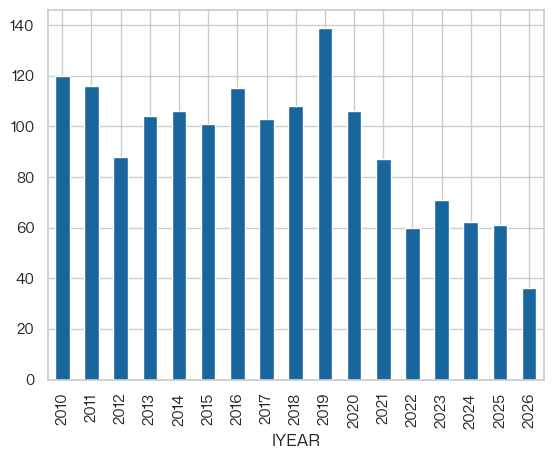

In [7]:
annual_incidents = incidents.groupby('IYEAR').count()['REPORT_NUMBER']
annual_incidents.plot(kind='bar')